# Monte Carlo Methods for Option Pricing

## Introduction

In finance, an option is a type of financial derivative which gives the owner the right (but not the obligation) to purchase (calls) or to sell (puts) a certain stock at a set strike price from being issued until expiration. 

The financial flexibility options provide comes at a premium. Working out the correct price of an option is necessary for fair value and to manage risk. In standard pricing theory, the price of an option should reflect the discounted expected payoff under a risk-neutral measure. However, markets are often complex systems to model numerically. Black-Scholes algebraically prices European options, while exotic options such as Asian options require a different approach. 

Monte Carlo methods provide an alternative numerical approach to estimating the value of financial derivatives by simulating a large number of possible future asset-price paths. This project explores the application of Monte Carlo simulation to European option pricing using a Geometric Brownian Motion (GBM) model, with historical SHEL.L price data used to estimate the stock's volatility.

The simulated stock-price paths are generated under the risk-neutral measure,

$$
dS_t = rS_t dt + \sigma S_t dW_t,
$$

where $r$ is the risk-free interest rate and $\sigma$ is the volatility estimated from historical price data. The resulting prices at expiry are used to calculate option payoffs, which are discounted to obtain a Monte Carlo estimate of the option value.

The European put price obtained through Monte Carlo simulation is compared with the analytical Black–Scholes solution. This provides a benchmark against which the accuracy of the numerical method can be assessed. The convergence of the Monte Carlo estimator is then investigated as the number of simulated paths increases, including an empirical measurement of the expected $(O(N^{-1/2}))$ convergence rate. Finally, antithetic variates are implemented as a variance-reduction technique. The standard Monte Carlo estimator is compared with its antithetic counterpart to investigate the reduction in estimator variance while maintaining the same underlying pricing model.

In summary, this notebook demonstrates and investigates the numerical behaviour of Monte Carlo pricing and the effectiveness of antithetic variates for variance reduction.

In [1]:
#importing dependencies
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
from utils import OptionPricer

## Defining the Option

In [2]:
# download SHEL.L stock price data in GBX
price_data = yf.download(
    'SHEL.L', 
    start='2010-01-01', 
    end='2025-01-01'
)

[*********************100%***********************]  1 of 1 completed


In [3]:
trading_days = 252

# S_0 calculated as latest adjusted close price
S_0 = price_data["Close"].iloc[-1].to_numpy()[0] 
K = S_0                            
T = 1                            
dt = T / trading_days 
# SONIA rate (annualised)
r = 0.047                        

# historical drift
log_returns = np.log(
    price_data["Close"] / price_data["Close"].shift(1)
)
log_returns = log_returns.dropna()
sigma = np.sqrt(trading_days) * log_returns.std(ddof=1).to_numpy()[0]  

# Random seed for reproducability
seed = 20

Pricer = OptionPricer(
    S_0,
    r,
    sigma,
    T,
    K,
    seed
)

## Monte Carlo Option Pricer Demonstration

Monte Carlo Option Prices Standard Deviation: 284.09


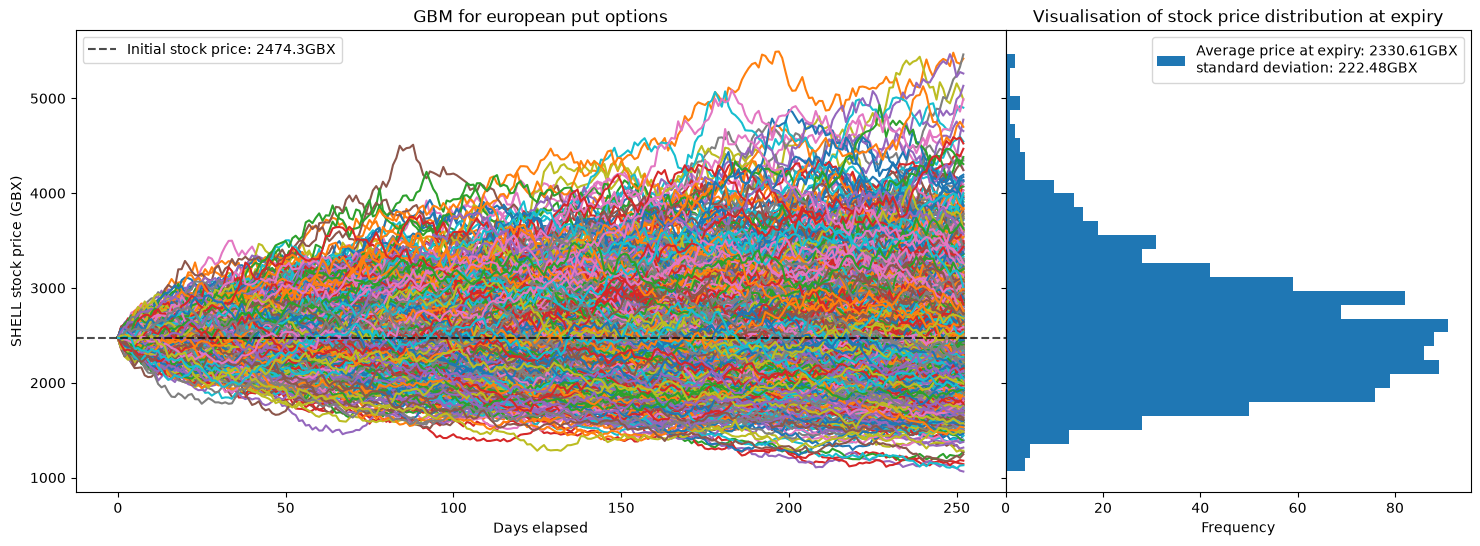

,Method,Option Price
0,Monte Carlo,203.833557
1,Black-Scholes,202.382176


In [4]:
simulations = 1000

V_MC = Pricer.visualise_GBM(
    simulations, 
    dt, 
    market_type="european", 
    option_type = "put"
)

V_BS = Pricer.Black_Scholes("put")

display(
    pd.DataFrame({
        "Method": ["Monte Carlo", "Black-Scholes"],
        "Option Price": [V_MC, V_BS]
    })
)

The Monte Carlo estimate well aproximates Black-Scholes' algebraic option price, with a percentage error of 0.72%. This demonstrates that Monte Carlo is a viable way of determining the price of an option. This is useful as the Black-Scholes equation is limited in scope. For example, it is only applicable to European options. Monte Carlo however can be applied to other types of options, such as Asian options where options are calculated by average prices over the lifetime of the option, instead of price at expiry. Feel free to change market_type to "asian" to see this functionality. 

## Monte Carlo Convergence Analysis

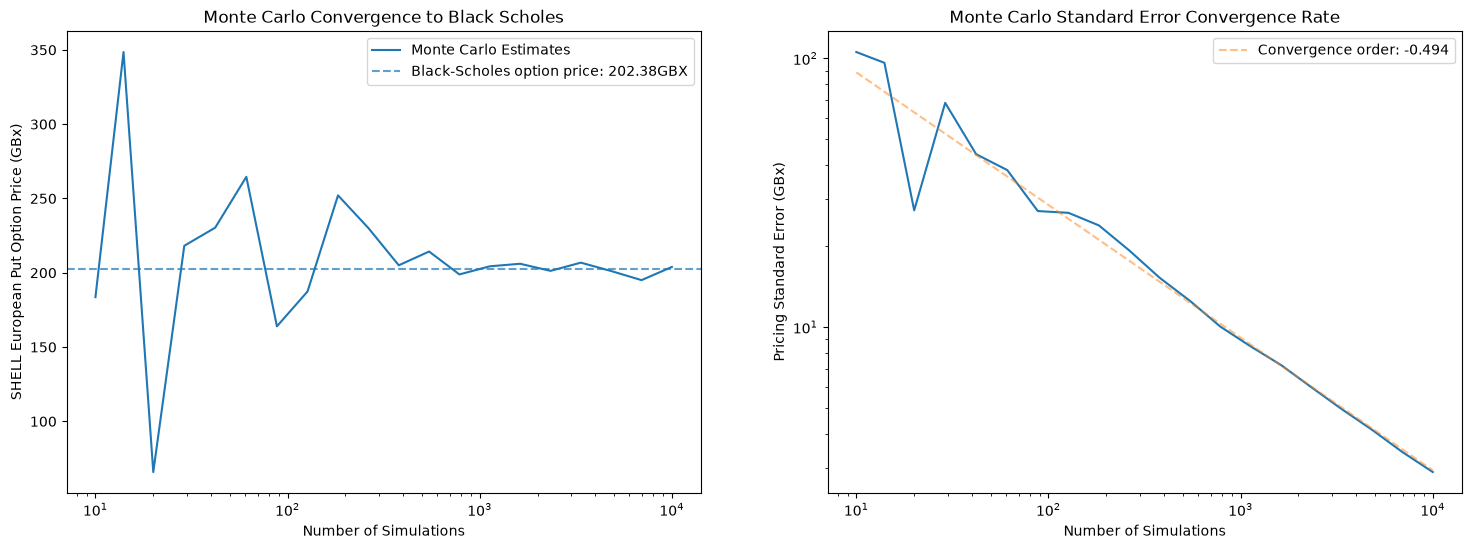

In [5]:
simulation_values = np.logspace(1, 4, 20).astype(int)
Vn_values = []
Vn_SE_values = []

for N in simulation_values:
    
    paths = Pricer.GBM_model(N, dt)
    payoffs = Pricer.payoff(
        paths, 
        market_type="european", 
        option_type="put"
    )
    
    Vn = np.exp(-r*T) * payoffs
    Vn_values.append(Vn.mean())
    standard_error = Vn.std(ddof=1) /  np.sqrt(N)
    Vn_SE_values.append(standard_error)

fig, (ax_E, ax_SE) = plt.subplots(
    1, 2, 
    figsize=(18,6)
)

ax_E.semilogx(simulation_values, Vn_values, label="Monte Carlo Estimates")
ax_E.axhline(V_BS, linestyle="--", alpha=0.7, label=f"Black-Scholes option price: {V_BS:.2f}GBX")

ax_E.set_xlabel("Number of Simulations")
ax_E.set_ylabel("SHELL European Put Option Price (GBx)")
ax_E.set_title("Monte Carlo Convergence to Black Scholes")
ax_E.legend()


# Plotting loglog SE plot with linear regression
ax_SE.loglog(simulation_values, Vn_SE_values)

x_exp = 10**(np.linspace(1, 4, 50))
m, c, r, p, se = linregress(np.log(simulation_values), np.log(Vn_SE_values))
y_exp = x_exp**m * np.exp(c)

ax_SE.loglog(x_exp, y_exp, linestyle="--", alpha=0.5, label=f"Convergence order: {m:.3f}")

ax_SE.set_xlabel("Number of Simulations")
ax_SE.set_ylabel("Pricing Standard Error (GBx)")
ax_SE.set_title("Monte Carlo Standard Error Convergence Rate")
ax_SE.legend()

plt.show()
plt.close()

The left plot demonstrates how Monte Carlo option price estimates converge to the Black-Scholes price as the number of simulations N increases. This is fundamental as it means that the Monte Carlo option price is a better estimate as N increases.

The right loglog standard error plot demonstrates the convergence rate of the Monte Carlo estimates to the Black-Scholes value. The experimental convergence order of -0.494, determined by the gradient of the regression line, agrees with the theoretical value of -0.5. 

Hence, this demonstrates how Monte Carlo option prices for european option converge to the Black-Scholes price as $O(N^{-\frac{1}{2}})$.

## Implementing Antithetic Variates

Monte Carlo Option Prices Standard Deviation: 149.33


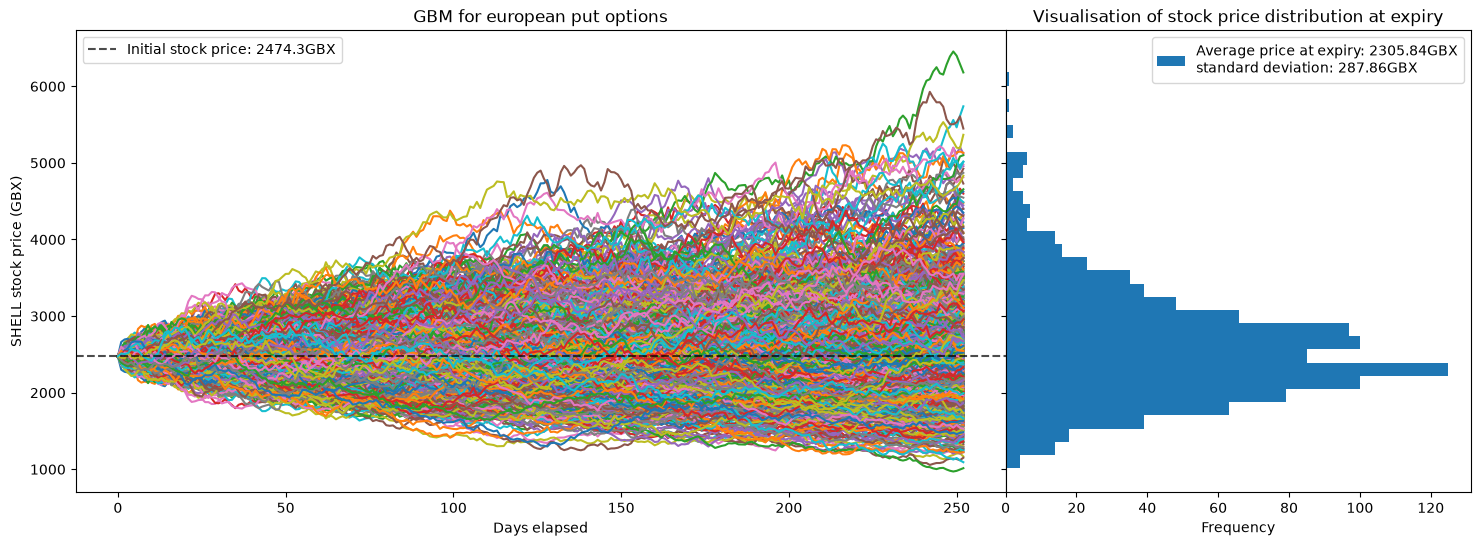

,Method,Option Price
0,Monte Carlo (AV),204.296828
1,Black-Scholes,202.382176


In [6]:
V_MC_AV = Pricer.visualise_GBM(
    simulations, 
    dt, 
    market_type="european", 
    option_type = "put", 
    antithetic_var=True
)

display(
    pd.DataFrame({
        "Method": ["Monte Carlo (AV)", "Black-Scholes"],
        "Option Price": [V_MC_AV, V_BS]
    })
)

The use of antithetic variates gave a 49.4% reduction in the standard deviation of option prices, corresponding to a 74.4% reduction in variance. 

## Conclusions

* Monte Carlo option pricing is effective, as validated against Black–Scholes for European options.
* Ordinary Monte Carlo estimates converge to Black-Scholes for European options at $O(N^{\frac{-1}{2}})$
* Antithetic variates can provide significant reductions in option price variance, enabling precise estimates to be produced with less computation steps.